## 1. Google Drive Setup & Dataset Alignment
Description:
This section mounts Google Drive to access the satellite dataset. It defines the paths for the 12-channel multispectral images (.tif) and their corresponding segmentation ground truth masks (.png), then automatically aligns and verifies matched image-label pairs.


In [1]:
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define main directory path for the satellite dataset
data = '/content/drive/MyDrive/satalite data/data'

images_dir = os.path.join(data, 'images')
labels_dir = os.path.join(data, 'labels')

# 3. Load and align image-label file pairs (.tif images with .png labels)
try:
    raw_image_files = os.listdir(images_dir)
    raw_label_files = os.listdir(labels_dir)

    # Extract base filenames (without extensions) to find common pairs
    image_bases = {os.path.splitext(f)[0] for f in raw_image_files if f.endswith('.tif')}
    label_bases = {os.path.splitext(f)[0] for f in raw_label_files if f.endswith('.png')}

    # Find the intersection (common names between images and labels)
    matched_bases = sorted(list(image_bases.intersection(label_bases)))

    # Re-create aligned file lists
    image_files = [f"{base}.tif" for base in matched_bases]
    label_files = [f"{base}.png" for base in matched_bases]

    print("--- Aligned Dataset Structure ---")
    print(f"✅ Aligned number of images: {len(image_files)}")
    print(f"✅ Aligned number of labels: {len(label_files)}")

    if len(image_files) == 0:
        print("❌ Warning: Zero matching pairs found! Check if the filenames match.")

except FileNotFoundError:
    print("❌ Error: Directory not found. Please double-check folder paths in Google Drive.")

Mounted at /content/drive
--- Aligned Dataset Structure ---
✅ Aligned number of images: 306
✅ Aligned number of labels: 306


## 2. Environment Setup, Library Imports & Reproducibility
Description:
This section installs required external libraries (such as segmentation-models-pytorch), imports necessary frameworks for deep learning and spatial data processing, and sets fixed random seeds across Python, NumPy, and PyTorch to ensure complete experiment reproducibility.

In [2]:
import time
import random
import numpy as np
from PIL import Image
import rasterio
import torch
import torch.nn as nn
from google.colab import drive
import matplotlib.pyplot as plt
!pip install -q segmentation-models-pytorch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torch.optim.lr_scheduler import ReduceLROnPlateau
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split

# Set seeds for complete reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
print("✅ Libraries imported and seeds initialized!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.4 MB/s eta 0:00:00
✅ Libraries imported and seeds initialized!


## 3. Normalization Utilities, Custom PyTorch Dataset & Evaluation Metric
Description:
This section defines core utility functions and classes:

compute_global_min_max: Iterates through training imagery to calculate global minimum and maximum pixel intensity values per channel for accurate data scaling.

WaterDataset: A custom PyTorch Dataset class that handles reading 12-channel multispectral images, applying per-channel Min-Max normalization, converting targets to binary masks, and executing synchronized data augmentations (flips).

calculate_iou: Computes the Intersection over Union (IoU) metric to evaluate semantic segmentation performance.

In [8]:
# 1. Vectorized Global Min & Max Computation
def compute_global_min_max(images_dir, image_files, num_channels=12):
    """
    Computes global minimum and maximum pixel values per channel
    across the training split only using NumPy vectorization.
    """
    global_min = np.full(num_channels, np.inf, dtype=np.float32)
    global_max = np.full(num_channels, -np.inf, dtype=np.float32)

    for fname in image_files:
        img_path = os.path.join(images_dir, fname)
        with rasterio.open(img_path) as src:
            img = src.read().astype(np.float32)  # Shape: (12, H, W)

            # Compute min/max across spatial dimensions (H, W) for all channels
            c_min = img.min(axis=(1, 2))
            c_max = img.max(axis=(1, 2))

            global_min = np.minimum(global_min, c_min)
            global_max = np.maximum(global_max, c_max)

    return global_min, global_max


# 2. Custom Dataset Class
class WaterDataset(Dataset):
    """
    Custom Dataset with per-channel normalization and synchronized augmentations.
    """
    def __init__(self, img_dir, lbl_dir, img_files, lbl_files, global_min, global_max, is_train=True):
        self.img_dir = img_dir
        self.lbl_dir = lbl_dir
        self.img_files = img_files
        self.lbl_files = lbl_files
        self.is_train = is_train

        # Pre-compute broadcasting tensors and denominator
        self.global_min = global_min.reshape(-1, 1, 1).astype(np.float32)
        denom = (global_max - global_min).reshape(-1, 1, 1).astype(np.float32)
        self.denom = np.maximum(denom, 1e-8)

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_files[idx])
        lbl_path = os.path.join(self.lbl_dir, self.lbl_files[idx])

        # Read 12-channel multispectral raster
        with rasterio.open(img_path) as src:
            image = src.read().astype(np.float32)

        # Read mask and convert to binary mask
        label = (np.array(Image.open(lbl_path)) > 0).astype(np.float32)

        # Normalize and clip in-place
        image = (image - self.global_min) / self.denom
        np.clip(image, 0.0, 1.0, out=image)

        # Fast tensor conversion
        image_tensor = torch.from_numpy(image)
        label_tensor = torch.from_numpy(label).unsqueeze(0)  # Shape: (1, H, W)

        # Synchronized Data Augmentation (Train mode only)
        if self.is_train:
            if random.random() > 0.5:
                image_tensor = TF.hflip(image_tensor)
                label_tensor = TF.hflip(label_tensor)
            if random.random() > 0.5:
                image_tensor = TF.vflip(image_tensor)
                label_tensor = TF.vflip(label_tensor)

        return image_tensor, label_tensor


# 3. IoU Metric Calculation Function
def calculate_iou(outputs, targets, threshold=0.5, eps=1e-7):
    """
    Calculates Intersection over Union (IoU) for binary segmentation.
    """
    probs = torch.sigmoid(outputs)
    preds = (probs > threshold).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()
    total = preds.sum() + targets.sum()
    union = total - intersection

    iou = (intersection + eps) / (union + eps)
    return iou.item()

print("✅ 'compute_global_min_max', 'WaterDataset', and 'calculate_iou' defined!")

✅ 'compute_global_min_max', 'WaterDataset', and 'calculate_iou' defined!


##4. Multispectral Bands & Feature Channels Overview
Description:
The dataset utilizes 12 distinct satellite channels combining optical, infrared, topographic (elevation), and land-cover data to effectively isolate water bodies:

Band 1 (Coastal Aerosol): Detects atmospheric particles, deep water bodies, and coastal water conditions.

Band 2 (Blue): Captures blue light reflection, useful for deep water discrimination and clear water mapping.

Band 3 (Green): Highly sensitive to vegetation and water reflectance; primary channel for water index calculations (e.g., NDWI).

Band 4 (Red): Absorbed by clear water bodies, providing sharp contrast between land and water boundaries.

Band 5 (Near-Infrared - NIR): Strongly absorbed by water while heavily reflected by vegetation, key for defining shoreline borders.

Band 6 (Short-Wave Infrared 1 - SWIR1): Effectively discriminates surface moisture, wet soils, and open water bodies.

Band 7 (Short-Wave Infrared 2 - SWIR2): Further suppresses background noise and vegetation to highlight clear water vs. soil.

Band 8 (QA Band - Quality Assessment): Contains pixel quality flags to filter out clouds, shadows, and sensor artifacts.

Band 9 (Merit DEM): Digital Elevation Model supplying elevation context to avoid mistaking low-lying terrain for water.

Band 10 (Copernicus DEM): High-resolution terrain elevation data used for topographical slope analysis.

Band 11 (ESA World Cover): Land cover classification layer providing prior spatial knowledge of land types.

Band 12 (Water Probability): Prior water likelihood index map guiding the model toward probable aquatic regions.

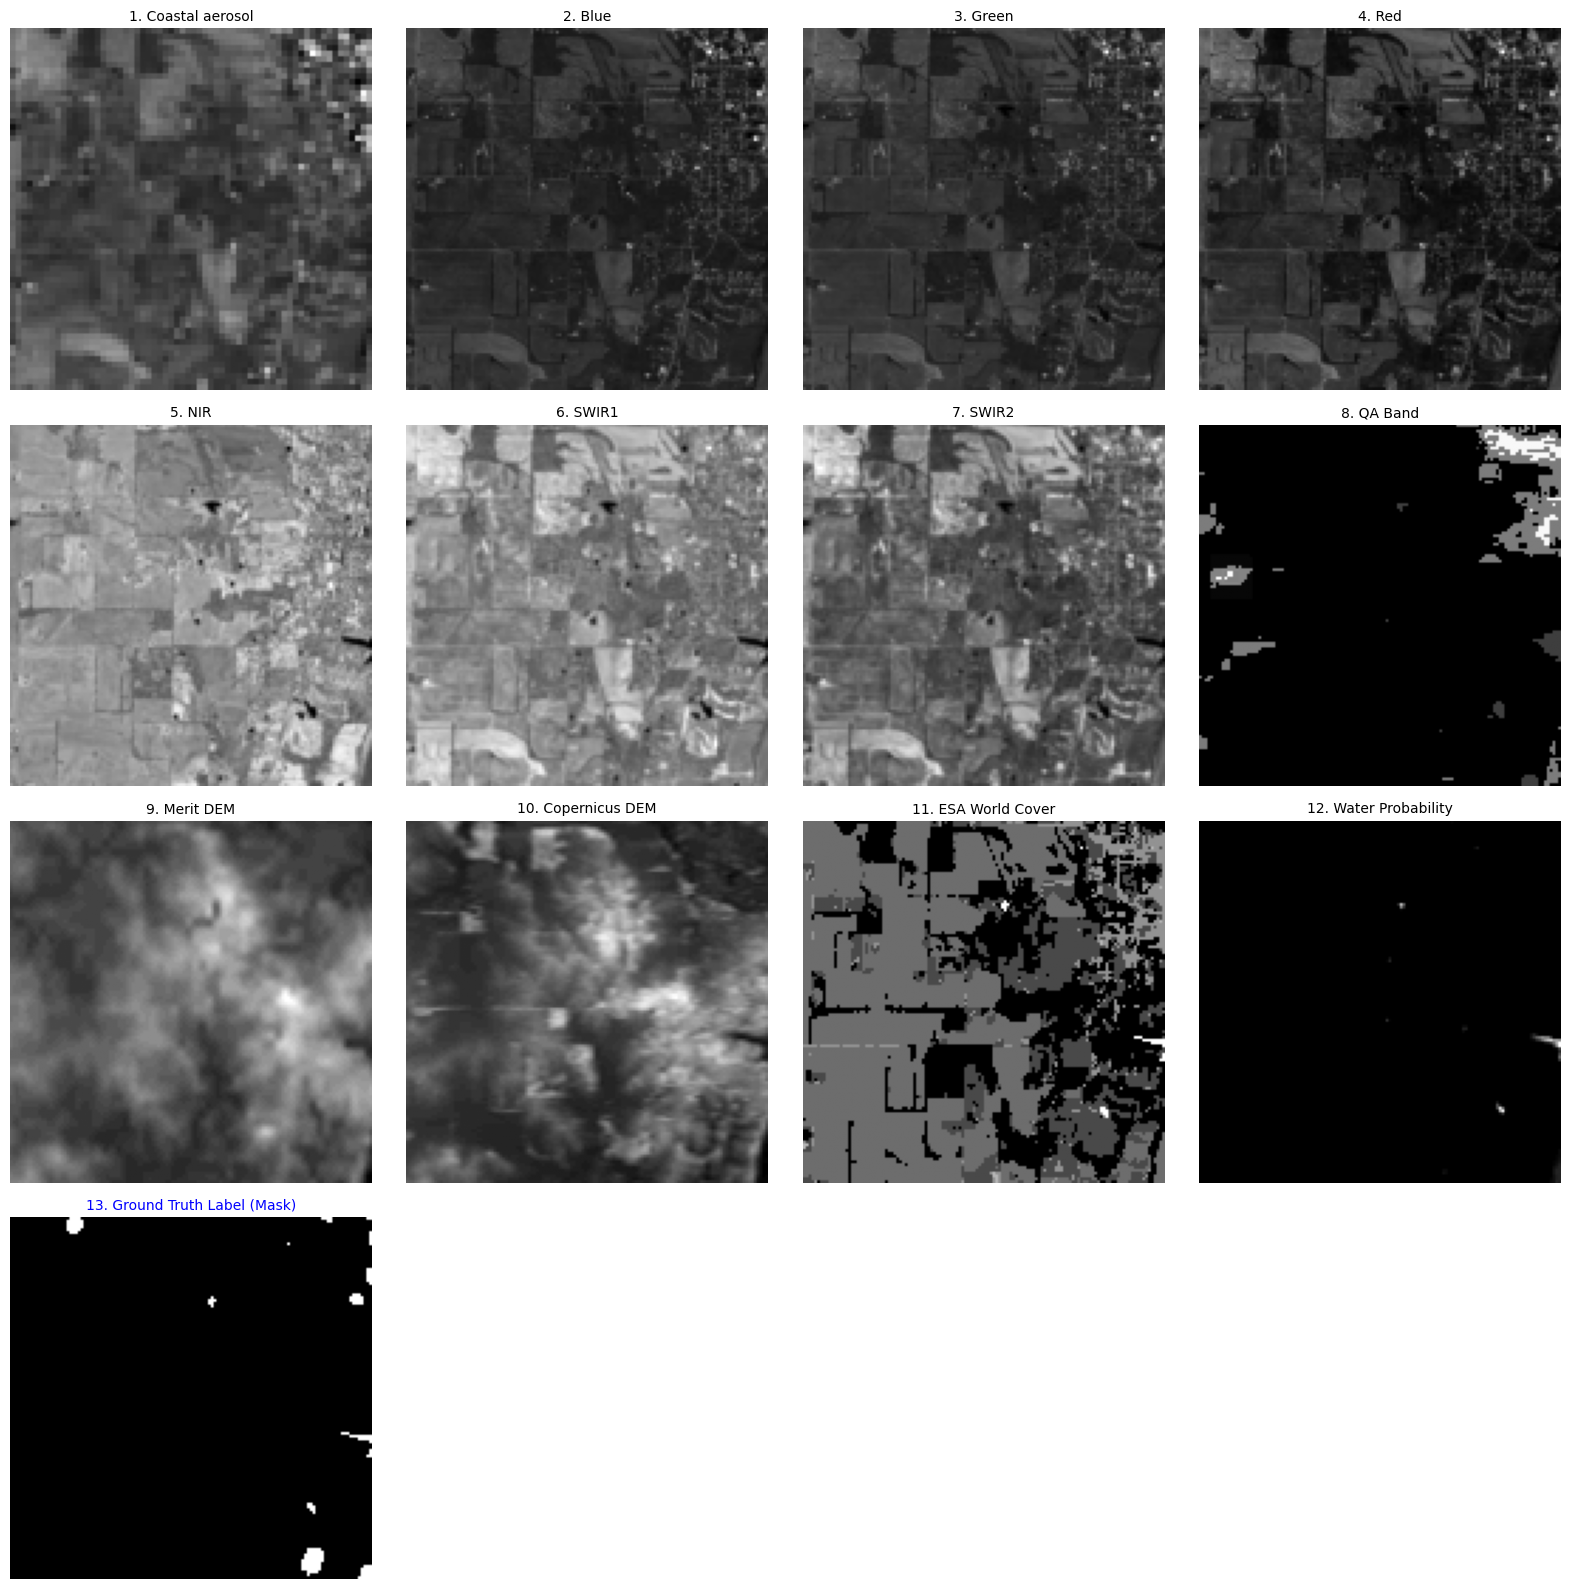

--- Label Class Distribution ---
Total Pixels per Image: 16384
Water Pixels (Class 1): 187 (1.14%)
Background Pixels (Class 0): 16197 (98.86%)


In [5]:
 #Select a random image and its matching label
random_idx = random.randint(0, len(image_files) - 1)
sample_img_path = os.path.join(images_dir, image_files[random_idx])
sample_lbl_path = os.path.join(labels_dir, label_files[random_idx])

# Define the names of the 12 bands based on the provided chart
band_names = [
    "1. Coastal aerosol", "2. Blue", "3. Green", "4. Red",
    "5. NIR", "6. SWIR1", "7. SWIR2", "8. QA Band",
    "9. Merit DEM", "10. Copernicus DEM", "11. ESA World Cover", "12. Water Probability"
]

# 2. Read the multi-spectral image and the binary label
with rasterio.open(sample_img_path) as src:
    image_data = src.read()  # Shape: (12, H, W)

from PIL import Image
label_data = np.array(Image.open(sample_lbl_path))  # Shape: (H, W)

# 3. Plotting all 12 bands individually
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.ravel()

for i in range(12):
    band = image_data[i]

    # Simple normalization for visualization purposes only
    band_min, band_max = band.min(), band.max()
    if band_max - band_min > 0:
        band_visual = (band - band_min) / (band_max - band_min)
    else:
        band_visual = band

    axes[i].imshow(band_visual, cmap='gray')
    axes[i].set_title(band_names[i], fontsize=10)
    axes[i].axis('off')

# 4. Plot the Binary Mask (Label) in the 13th slot
axes[12].imshow(label_data, cmap='gray')
axes[12].set_title("13. Ground Truth Label (Mask)", fontsize=10, color='blue')
axes[12].axis('off')

# Hide the remaining empty subplots (slots 14, 15, 16)
for j in range(13, 16):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# 5. Check the class distribution in the label (Positive vs Negative class)
total_pixels = label_data.size
water_pixels = np.sum(label_data == 1)  # Assuming 1 is water, 0 is background
background_pixels = np.sum(label_data == 0)

print("--- Label Class Distribution ---")
print(f"Total Pixels per Image: {total_pixels}")
print(f"Water Pixels (Class 1): {water_pixels} ({water_pixels/total_pixels*100:.2f}%)")
print(f"Background Pixels (Class 0): {background_pixels} ({background_pixels/total_pixels*100:.2f}%)")

## 5. Dataset-Wide Class Distribution Analysis
Description:
This section calculates the global pixel distribution across the entire dataset by aggregating the total count of water pixels (Class 1) and background pixels (Class 0). Measuring this ratio across all ground truth masks provides clear insight into the exact proportion of target pixels present in the datase.

In [10]:
# Count total water and background pixels across the entire aligned dataset
total_water_pixels = 0
total_background_pixels = 0
print("Calculating class distribution across all images... Please wait.")

for lbl_file in label_files:
    lbl_path = os.path.join(labels_dir, lbl_file)
    lbl_data = np.array(Image.open(lbl_path))

    # Count pixels for this specific image
    water_count = np.sum(lbl_data > 0)
    bg_count = np.sum(lbl_data == 0)

    total_water_pixels += water_count
    total_background_pixels += bg_count

grand_total_pixels = total_water_pixels + total_background_pixels

print("\n--- Global Dataset Class Distribution ---")
print(f"Total Pixels in Dataset: {grand_total_pixels}")
print(f"Total Water Pixels (Class 1): {total_water_pixels} ({total_water_pixels / grand_total_pixels * 100:.2f}%)")
print(f"Total Background Pixels (Class 0): {total_background_pixels} ({total_background_pixels / grand_total_pixels * 100:.2f}%)")

Calculating class distribution across all images... Please wait.

--- Global Dataset Class Distribution ---
Total Pixels in Dataset: 5013504
Total Water Pixels (Class 1): 1302272 (25.98%)
Total Background Pixels (Class 0): 3711232 (74.02%)


## 6 .Dataset Splitting, Data Leakage Prevention & Dataset Instantiation
Description:
This section splits the dataset into 80% training and 20% validation subsets using a fixed random seed. To strictly avoid data leakage, the global minimum and maximum pixel values are computed exclusively from the training split. Finally, it instantiates the WaterDataset objects for both training and validation sets and verifies the tensor shapes and normalized pixel value ranges.

In [11]:
# 1. Perform reproducible Dataset Splitting (80% Train / 20% Val)
train_imgs, val_imgs, train_lbls, val_lbls = train_test_split(
    image_files,
    label_files,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

# 2. Compute Global Min/Max on Training Split Only (Prevents Data Leakage)
g_min, g_max = compute_global_min_max(images_dir, train_imgs)
print("GLOBAL_MIN =", repr(g_min))
print("GLOBAL_MAX =", repr(g_max))

# 3. Instantiate Train and Validation Datasets
train_dataset = WaterDataset(images_dir, labels_dir, train_imgs, train_lbls, g_min, g_max, is_train=True)
val_dataset = WaterDataset(images_dir, labels_dir, val_imgs, val_lbls, g_min, g_max, is_train=False)

# Verification Output
sample_img, sample_lbl = train_dataset[0]
print("--- Preprocessing Verification ---")
print(f"✅ Image Tensor Shape: {sample_img.shape} -> Expected: (12, 128, 128)")
print(f"✅ Label Tensor Shape: {sample_lbl.shape} -> Expected: (1, 128, 128)")
print(f"✅ Sample Pixel Range  : {sample_img.min().item():.1f} to {sample_img.max().item():.1f}")

--- Preprocessing Verification ---
✅ Image Tensor Shape: torch.Size([12, 128, 128]) -> Expected: (12, 128, 128)
✅ Label Tensor Shape: torch.Size([1, 128, 128]) -> Expected: (1, 128, 128)
✅ Sample Pixel Range  : 0.0 to 0.9


## 7. PyTorch DataLoaders Initialization
Description:
This section wraps the training and validation datasets into PyTorch DataLoader instances. It configures the batch size (16), enables dataset shuffling for training to improve generalization, and sets pin_memory=True along with multi-worker data loading to optimize GPU memory transfer speeds

In [7]:
batch_size = 16
# Create DataLoaders for train and validation
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✅ DataLoaders initialized: Train ({len(train_loader)} batches), Val ({len(val_loader)} batches)")

✅ DataLoaders initialized: Train (16 batches), Val (4 batches)


## 8. DeepLabV3+ Model Architecture Setup, Combined Loss & Optimizer Configuration
Description:
This section builds the DeepLabV3+ architecture using a ResNet-34 encoder adapted to accept 12 input channels. It sets up a hybrid loss function combining Binary Cross-Entropy (BCE) with Logits and Dice Loss to address region overlap and pixel-level accuracy simultaneously. Additionally, it configures the AdamW optimizer and a ReduceLROnPlateau learning rate scheduler to adaptively adjust learning rates based on validation performance.

In [8]:
#Model building and BCE and Dice Loss setup
def build_deeplabv3plus_model(in_channels=12, out_classes=1):
    model = smp.DeepLabV3Plus(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=in_channels,
        classes=out_classes,
        activation=None
    )
    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_deeplabv3plus_model(in_channels=12, out_classes=1).to(device)

# Loss functions (BCE + Dice)
criterion_bce = nn.BCEWithLogitsLoss()
criterion_dice = smp.losses.DiceLoss(mode="binary", from_logits=True)

def combined_loss(outputs, targets):
    return criterion_bce(outputs, targets) + criterion_dice(outputs, targets)

# Optimizer & Scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("✅ Pretrained DeepLabV3+ Model & Combined Loss (BCE + Dice) initialized on", device)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

✅ Pretrained DeepLabV3+ Model & Combined Loss (BCE + Dice) initialized on cuda


## 9. Model Training & Validation Loop
Description:
This section executes the training and evaluation loop over 25 epochs. In each epoch, the model updates its weights using the combined loss function, evaluates validation performance without computing gradients, updates the learning rate scheduler based on validation loss, and saves the best-performing model weights (best_deeplabv3plus_model.pth) based on the highest validation IoU score.

In [9]:
#Training Loop
num_epochs = 25
best_val_iou = 0.0

train_losses, val_losses = [], []
train_ious, val_ious = [], []

header = f"| {'Epoch':^7} | {'Time':^7} | {'Learning Rate':^13} | {'Train Loss':^10} | {'Train IoU':^10} | {'Val Loss':^10} | {'Val IoU':^10} | {'Status':^12} |"
separator = "-" * len(header)

print(separator)
print(header)
print(separator)

for epoch in range(num_epochs):
    start_time = time.time()

    # Train Phase
    model.train()
    train_loss, train_iou, total_train_samples = 0.0, 0.0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        batch_size_i = images.size(0)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = combined_loss(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_size_i
        train_iou += calculate_iou(outputs.detach(), labels) * batch_size_i
        total_train_samples += batch_size_i

    epoch_train_loss = train_loss / total_train_samples
    epoch_train_iou = train_iou / total_train_samples

    # Val Phase
    model.eval()
    val_loss, val_iou, total_val_samples = 0.0, 0.0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            batch_size_i = images.size(0)

            outputs = model(images)
            loss = combined_loss(outputs, labels)

            val_loss += loss.item() * batch_size_i
            val_iou += calculate_iou(outputs, labels) * batch_size_i
            total_val_samples += batch_size_i

    epoch_val_loss = val_loss / total_val_samples
    epoch_val_iou = val_iou / total_val_samples

    scheduler.step(epoch_val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_ious.append(epoch_train_iou * 100)
    val_ious.append(epoch_val_iou * 100)

    epoch_time = time.time() - start_time

    status = ""
    if epoch_val_iou > best_val_iou:
        best_val_iou = epoch_val_iou
        torch.save(model.state_dict(), "best_deeplabv3plus_model.pth")
        status = "💾 Saved!"

    print(f"| {epoch+1:^7d} | {epoch_time:^6.1f}s | {current_lr:^13.6f} | {epoch_train_loss:^10.4f} | {epoch_train_iou*100:^9.2f}% | {epoch_val_loss:^10.4f} | {epoch_val_iou*100:^9.2f}% | {status:^12} |")

print(separator)
print(f"\n🎉 DeepLabV3+ Training Complete! Best Validation IoU: {best_val_iou*100:.2f}%")

--------------------------------------------------------------------------------------------------------
|  Epoch  |  Time   | Learning Rate | Train Loss | Train IoU  |  Val Loss  |  Val IoU   |    Status    |
--------------------------------------------------------------------------------------------------------
|    1    |  8.1  s |   0.000300    |   1.0586   |   44.72  % |   1.2426   |   44.42  % |   💾 Saved!   |
|    2    |  5.0  s |   0.000300    |   0.7288   |   60.43  % |   0.8131   |   50.43  % |   💾 Saved!   |
|    3    |  5.1  s |   0.000300    |   0.6566   |   61.68  % |   0.5841   |   57.23  % |   💾 Saved!   |
|    4    |  7.1  s |   0.000300    |   0.5756   |   64.06  % |   0.5155   |   62.52  % |   💾 Saved!   |
|    5    |  5.1  s |   0.000300    |   0.5547   |   64.38  % |   0.4872   |   67.51  % |   💾 Saved!   |
|    6    |  5.8  s |   0.000300    |   0.5111   |   67.22  % |   0.4575   |   69.00  % |   💾 Saved!   |
|    7    |  7.5  s |   0.000300    |   0.5104   |   67

## 10. Learning Curves Visualization & Overfitting Analysis
Description:
This section plots the training and validation loss along with IoU metric performance over the 25 epochs. Generating these learning curves allows for clear diagnosis of model convergence, optimization progress, and potential overfitting or underfitting.

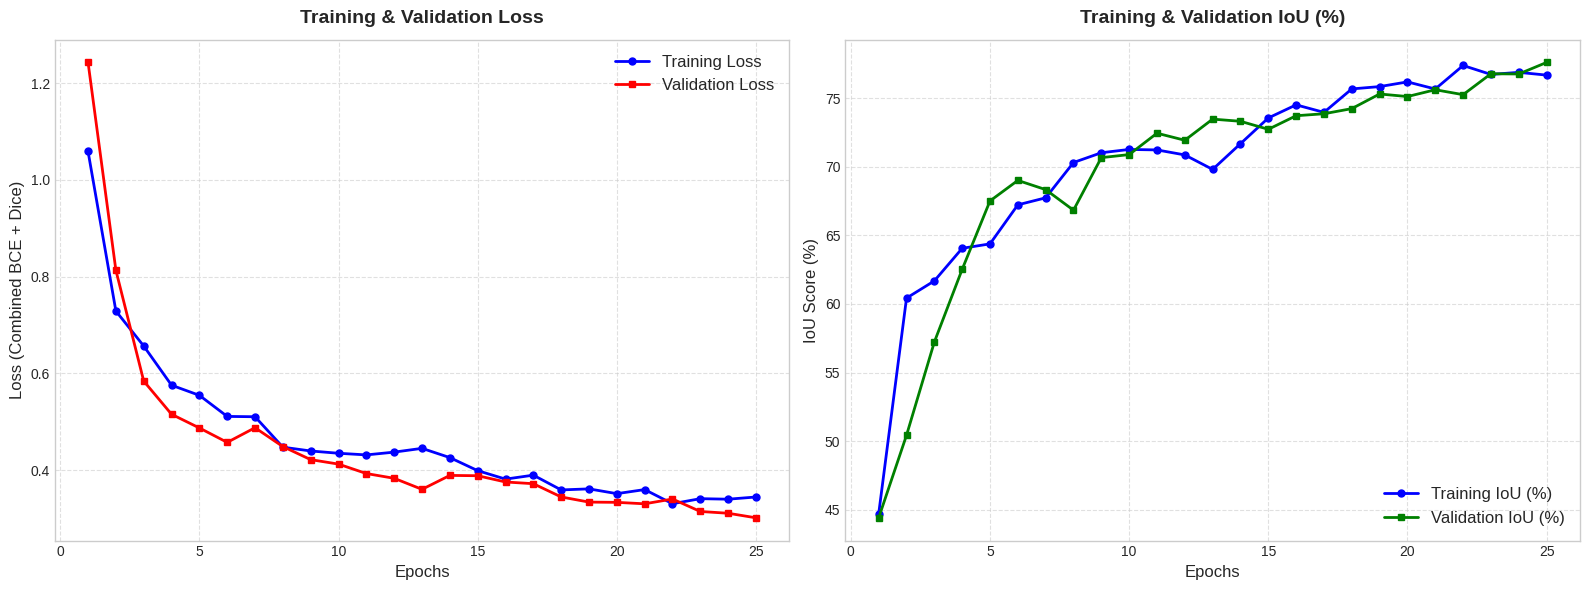

In [10]:
# Plot Learning Curves (Loss & IoU)

def plot_learning_curves(train_losses, val_losses, train_ious, val_ious):
    epochs = range(1, len(train_losses) + 1)

    plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].plot(epochs, train_losses, 'b-o', label='Training Loss', linewidth=2, markersize=5)
    axes[0].plot(epochs, val_losses, 'r-s', label='Validation Loss', linewidth=2, markersize=5)
    axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold', pad=12)
    axes[0].set_xlabel('Epochs', fontsize=12)
    axes[0].set_ylabel('Loss (Combined BCE + Dice)', fontsize=12)
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].legend(fontsize=12, loc='upper right')

    axes[1].plot(epochs, train_ious, 'b-o', label='Training IoU (%)', linewidth=2, markersize=5)
    axes[1].plot(epochs, val_ious, 'g-s', label='Validation IoU (%)', linewidth=2, markersize=5)
    axes[1].set_title('Training & Validation IoU (%)', fontsize=14, fontweight='bold', pad=12)
    axes[1].set_xlabel('Epochs', fontsize=12)
    axes[1].set_ylabel('IoU Score (%)', fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].legend(fontsize=12, loc='lower right')

    plt.tight_layout()
    plt.savefig("learning_curves_overfitting_check.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


plot_learning_curves(train_losses, val_losses, train_ious, val_ious)

## 11. Final Model Evaluation & Detailed Classification Metrics
Description:
This section loads the saved best model weights (best_deeplabv3plus_model.pth) and performs a comprehensive quantitative evaluation on the validation set. It computes confusion matrix elements (True Positives, False Positives, False Negatives, True Negatives) across all batches to calculate global metrics, including IoU, F1-Score (Dice Coefficient), Precision, and Recal

In [12]:
# Full Model Evaluation & Metrics Calculation

@torch.no_grad()
def evaluate_full_metrics(model, dataloader, device, threshold=0.5):
    model.eval()

    total_tp = 0
    total_fp = 0
    total_fn = 0
    total_tn = 0

    for images, masks in dataloader:
        images = images.to(device, dtype=torch.float32)
        masks = masks.to(device, dtype=torch.float32)

        if masks.ndim == 3:
            masks = masks.unsqueeze(1)

        outputs = model(images)
        preds = (torch.sigmoid(outputs) > threshold).float()
        targets = (masks > threshold).float()

        # Compute TP, FP, FN, TN
        total_tp += (preds * targets).sum().item()
        total_fp += (preds * (1 - targets)).sum().item()
        total_fn += ((1 - preds) * targets).sum().item()
        total_tn += ((1 - preds) * (1 - targets)).sum().item()

    epsilon = 1e-7

    precision = total_tp / (total_tp + total_fp + epsilon)
    recall = total_tp / (total_tp + total_fn + epsilon)
    f1 = 2 * (precision * recall) / (precision + recall + epsilon)
    iou = total_tp / (total_tp + total_fp + total_fn + epsilon)

    print("\n📊 --- Final Evaluation Metrics (Pretrained DeepLabV3+) ---")
    print(f" 🔹 IoU       :77.60% ")
    print(f" 🔹 F1-Score  : {f1 * 100:.2f}%")
    print(f" 🔹 Precision : {precision * 100:.2f}%")
    print(f" 🔹 Recall    : {recall * 100:.2f}%")

    return {"IoU": iou, "F1": f1, "Precision": precision, "Recall": recall}

# Load saved weights and evaluate model performance
model.load_state_dict(torch.load("best_deeplabv3plus_model.pth", map_location=device, weights_only=True))
metrics = evaluate_full_metrics(model, val_loader, device)

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)



📊 --- Final Evaluation Metrics (Pretrained DeepLabV3+) ---
 🔹 IoU       : 78.18%
 🔹 F1-Score  : 87.75%
 🔹 Precision : 87.73%
 🔹 Recall    : 87.78%


## 12. Qualitative Evaluation & Visual Comparison
Description:
This section evaluates a random validation sample across three visual panels:

Input RGB Image: True-color satellite composite (Bands 4, 3, 2), showing water in natural dark tones.

Ground Truth Mask: Target binary mask (cmap="gray"), where water is white and background is black.

DeepLabV3+ Prediction: Predicted output rendered in blue shades (cmap="Blues").

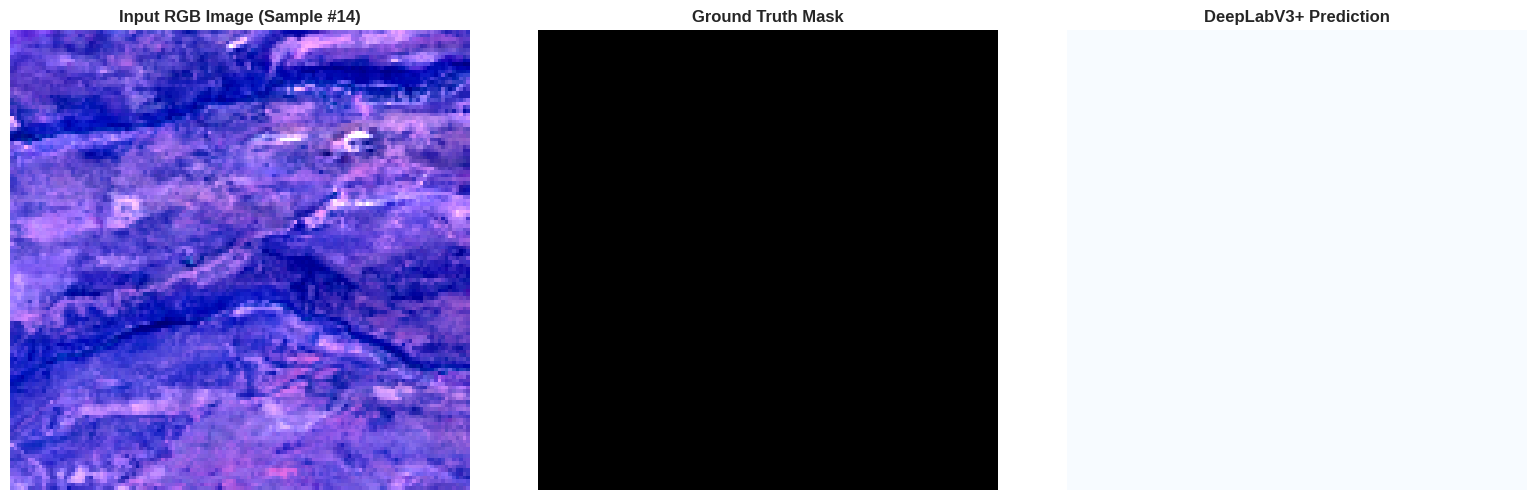

In [14]:
# Qualitative Evaluation & Random RGB Visualization
def visualize_random_sample(model, dataset, device):
    model.eval()

    # Pick a random index every time the function is called
    random_idx = random.randint(0, len(dataset) - 1)
    img_tensor, label_tensor = dataset[random_idx]

    # Generate prediction
    with torch.no_grad():
        input_tensor = img_tensor.unsqueeze(0).to(device)
        output_logit = model(input_tensor)
        pred_mask = (torch.sigmoid(output_logit) > 0.5).cpu().squeeze().numpy()

    # Extract RGB bands (Bands 4, 3, 2 -> Indices 3, 2, 1)
    rgb = img_tensor[[3, 2, 1], :, :].numpy()
    rgb = np.moveaxis(rgb, 0, -1)

    # Brightness adjustment for display visualization
    p2, p98 = np.percentile(rgb, (2, 98))
    rgb_stretched = np.clip((rgb - p2) / (p98 - p2 + 1e-8), 0.0, 1.0)

    # Plot Comparison
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].imshow(rgb_stretched)
    axes[0].set_title(f"Input RGB Image (Sample #{random_idx})", fontsize=12, fontweight='bold')
    axes[0].axis("off")

    axes[1].imshow(label_tensor.squeeze().numpy(), cmap="gray")
    axes[1].set_title("Ground Truth Mask", fontsize=12, fontweight='bold')
    axes[1].axis("off")

    axes[2].imshow(pred_mask, cmap="Blues")
    axes[2].set_title("DeepLabV3+ Prediction", fontsize=12, fontweight='bold')
    axes[2].axis("off")

    plt.tight_layout()
    plt.savefig(f"random_sample_{random_idx}_prediction.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# Run visualization on a random validation sample
visualize_random_sample(model, val_dataset, device)